In [1]:
import matplotlib.pyplot as plt
import random
import torch
import torchinfo
import torchvision

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

#### Podatkovna zbirka MNIST

Širina slik:       28
Višina slik:       28
Število kanalov:   1
Število slik:      60000


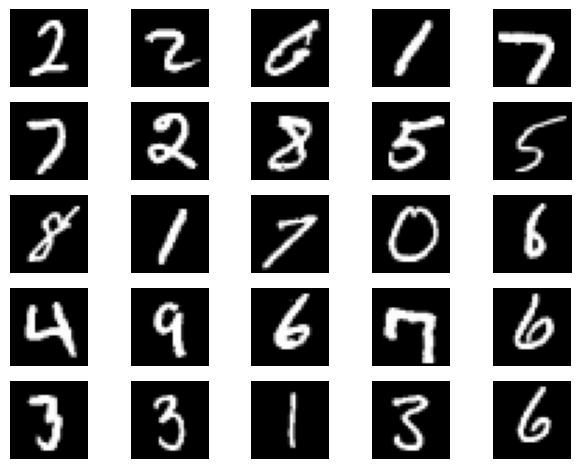

In [2]:
mnist_ds = torchvision.datasets.MNIST(root="datasets", train=True, transform=torchvision.transforms.ToTensor(), download=True)

print(f"Širina slik:       {mnist_ds[0][0].shape[2]}")
print(f"Višina slik:       {mnist_ds[0][0].shape[1]}")
print(f"Število kanalov:   {mnist_ds[0][0].shape[0]}")
print(f"Število slik:      {len(mnist_ds)}")

n_rows = 5
n_cols = 5
_, axes = plt.subplots(n_rows, n_cols)
for r in range(n_rows):
    for c in range(n_cols):
        img, _ = mnist_ds[random.randint(0, len(mnist_ds) - 1)]
        axes[r, c].imshow(img.permute(1, 2, 0), cmap="gray")
        axes[r, c].axis("off")
plt.tight_layout()

#### Nevronska mreža

In [3]:
# Parametri
epochs = 100
batch_size = 128 # (128 realnih in 128 generiranih slik)
vector_length = 100 # Latentni prostor - vektor 100 naključnih števil

# Model
from neural_network import *

#### Arhitektura diskriminatorja
- Optimizacijski algoritem: Adam
- Hitrost učenja: 0.0002
- Vrednost parametra Beta 1: 0.5
- Vrednost parametra Beta 2: 0.999
- Metrika izgube: Binary Cross-Entropy

In [4]:
discriminator = DiscriminatorModel()
discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

torchinfo.summary(discriminator, (batch_size, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
DiscriminatorModel                       [128, 1]                  --
├─Conv2d: 1-1                            [128, 64, 14, 14]         576
├─BatchNorm2d: 1-2                       [128, 64, 14, 14]         128
├─LeakyReLU: 1-3                         [128, 64, 14, 14]         --
├─Conv2d: 1-4                            [128, 64, 7, 7]           36,864
├─BatchNorm2d: 1-5                       [128, 64, 7, 7]           128
├─LeakyReLU: 1-6                         [128, 64, 7, 7]           --
├─Flatten: 1-7                           [128, 3136]               --
├─Linear: 1-8                            [128, 1]                  3,137
├─Sigmoid: 1-9                           [128, 1]                  --
Total params: 40,833
Trainable params: 40,833
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 246.10
Input size (MB): 0.40
Forward/backward pass size (MB): 32.11
Params size (MB): 0.16
Estimated Total Siz

#### Arhitektura generatorja
- Optimizacijski algoritem: Adam
- Hitrost učenja: 0.0002
- Vrednost parametra Beta 1: 0.5
- Vrednost parametra Beta 2: 0.999
- Metrika izgube: Binary Cross-Entropy

In [5]:
generator = GeneratorModel()
generator_optimizer = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))

torchinfo.summary(generator, (batch_size, vector_length))

Layer (type:depth-idx)                   Output Shape              Param #
GeneratorModel                           [128, 1, 28, 28]          --
├─Linear: 1-1                            [128, 6272]               633,472
├─ReLU: 1-2                              [128, 6272]               --
├─ConvTranspose2d: 1-3                   [128, 128, 14, 14]        262,272
├─BatchNorm2d: 1-4                       [128, 128, 14, 14]        256
├─ReLU: 1-5                              [128, 128, 14, 14]        --
├─ConvTranspose2d: 1-6                   [128, 128, 28, 28]        262,272
├─BatchNorm2d: 1-7                       [128, 128, 28, 28]        256
├─ReLU: 1-8                              [128, 128, 28, 28]        --
├─Conv2d: 1-9                            [128, 1, 28, 28]          6,273
├─Sigmoid: 1-10                          [128, 1, 28, 28]          --
Total params: 1,164,801
Trainable params: 1,164,801
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 33.61
Input size (MB): 0

In [6]:
# Učenje
loss_fn = torch.nn.BCELoss()

# DataLoader realnih slik
real_data_loader = torch.utils.data.DataLoader(mnist_ds, batch_size=batch_size, shuffle=True, num_workers=1, pin_memory=True, drop_last=True)

nn_train(discriminator, discriminator_optimizer, generator, generator_optimizer, loss_fn, real_data_loader, vector_length, epochs)

#### Rezultati

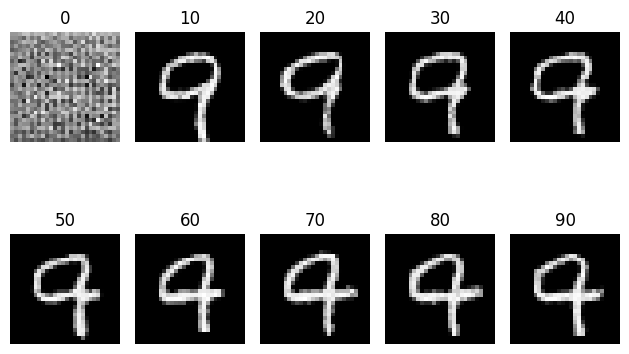

In [8]:
# Generiranje naključnega vektorja identitete
gen_input = torch.randn(1, vector_length, dtype=torch.float32, device=device)

e_list = list(range(0, 101, 10))
n_rows = 2
n_cols = 5
i = 0
_, axes = plt.subplots(n_rows, n_cols)
for r in range(n_rows):
    for c in range(n_cols):
        # Naložimo model
        gen_model = GeneratorModel()
        gen_model_load = torch.load(f"models/model__e_{e_list[i]}.pt", map_location=device)
        gen_model.load_state_dict(gen_model_load)
        gen_model.to(device)

        # Generiranje slike
        gen_output = gen_model(gen_input)
        img = gen_output[0].permute(1, 2, 0).detach().cpu().numpy()
        
        axes[r, c].imshow(img, cmap="gray")
        axes[r, c].set_title(e_list[i])
        axes[r, c].axis("off")
        i = i + 1
plt.tight_layout()